Second Practical Project - MINDD
-----
-----

Authors:
--------
Ana Rita Silva - 1211152

Jorge Cruz - 1221715


-----



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Data understanding and preparation

Loading the Data

In [28]:
energy_dataset = pd.read_csv("energy_dataset.csv")
weather_dataset = pd.read_csv("weather.csv")

df = pd.merge(energy_dataset, weather_dataset, on="time", how="inner")
df

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,generation_hydro_pumped_storage_aggregated,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_marine,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_wind_offshore_eday_ahead,total_load_actual,price_day_ahead,temperature,pressure,humidity,wind_speed
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,NaN,25385.0,50.10,272.491463,1021.3,82.4,2.0
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,NaN,24382.0,48.10,272.512700,1021.2,82.4,2.0
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,NaN,22734.0,47.33,272.151937,1021.6,82.0,2.4
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,NaN,21286.0,42.27,272.142269,1021.5,82.0,2.4
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,NaN,20264.0,38.41,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,0.0,7634.0,2628.0,178.0,0.0,0.0,0.0,NaN,1.0,1135.0,4836.0,0.0,6073.0,63.0,95.0,85.0,277.0,0.0,3113.0,NaN,30653.0,68.85,284.470000,1029.2,73.6,1.4
35060,2018-12-31 20:00:00+01:00,296.0,0.0,0.0,7241.0,2566.0,174.0,0.0,0.0,0.0,NaN,1.0,1172.0,3931.0,0.0,6074.0,62.0,95.0,33.0,280.0,0.0,3288.0,NaN,29735.0,68.40,282.294000,1030.0,68.0,1.8
35061,2018-12-31 21:00:00+01:00,292.0,0.0,0.0,7025.0,2422.0,168.0,0.0,0.0,0.0,NaN,50.0,1148.0,2831.0,0.0,6076.0,61.0,94.0,31.0,286.0,0.0,3503.0,NaN,28071.0,66.88,280.850000,1029.8,71.4,2.6
35062,2018-12-31 22:00:00+01:00,293.0,0.0,0.0,6562.0,2293.0,163.0,0.0,0.0,0.0,NaN,108.0,1128.0,2068.0,0.0,6075.0,61.0,93.0,31.0,287.0,0.0,3586.0,NaN,25801.0,63.93,279.718000,1030.2,70.0,2.8


### Data Types of the Columns

In [30]:
df.dtypes

time                                            object
generation_biomass                             float64
generation_fossil_brown_coal_lignite           float64
generation_fossil_coal-derived_gas             float64
generation_fossil_gas                          float64
generation_fossil_hard_coal                    float64
generation_fossil_oil                          float64
generation_fossil_oil_shale                    float64
generation_fossil_peat                         float64
generation_geothermal                          float64
generation_hydro_pumped_storage_aggregated     float64
generation_hydro_pumped_storage_consumption    float64
generation_hydro_run-of-river_and_poundage     float64
generation_hydro_water_reservoir               float64
generation_marine                              float64
generation_nuclear                             float64
generation_other                               float64
generation_other_renewable                     float64
generation

The dataset is composed almost entirely of numerical variables (**float64**), covering all energy generation measurements and weather-related data. The only non-numerical column is **time**, stored as an **object**, indicating a temporal value that should be converted to a proper datetime format.

##### Descriptive Analysis

In [31]:
df.info

<bound method DataFrame.info of                             time  generation_biomass  \
0      2015-01-01 00:00:00+01:00               447.0   
1      2015-01-01 01:00:00+01:00               449.0   
2      2015-01-01 02:00:00+01:00               448.0   
3      2015-01-01 03:00:00+01:00               438.0   
4      2015-01-01 04:00:00+01:00               428.0   
...                          ...                 ...   
35059  2018-12-31 19:00:00+01:00               297.0   
35060  2018-12-31 20:00:00+01:00               296.0   
35061  2018-12-31 21:00:00+01:00               292.0   
35062  2018-12-31 22:00:00+01:00               293.0   
35063  2018-12-31 23:00:00+01:00               290.0   

       generation_fossil_brown_coal_lignite  \
0                                     329.0   
1                                     328.0   
2                                     323.0   
3                                     254.0   
4                                     187.0   
...          

In [32]:
pd.set_option('display.max_columns', None)
df.describe()

,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,generation_hydro_pumped_storage_aggregated,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_marine,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_wind_offshore_eday_ahead,total_load_actual,price_day_ahead,temperature,pressure,humidity,wind_speed
count,35045.000000,35046.000000,35046.0,35046.000000,35046.000000,35045.000000,35046.0,35046.0,35046.0,0.0,35045.000000,35045.000000,35046.000000,35045.0,35047.000000,35046.000000,35046.000000,35046.000000,35045.000000,35046.0,35046.000000,0.0,35028.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,NaN,475.577343,972.116108,2605.114735,0.0,6263.907039,60.228585,85.639702,1432.665925,269.452133,0.0,5464.479769,NaN,28696.939905,49.874341,289.706862,1017.297872,68.033025,2.442944
std,85.353943,354.568590,0.0,2201.830478,1961.601013,52.520673,0.0,0.0,0.0,NaN,792.406614,400.777536,1835.199745,0.0,839.667958,20.238381,14.077554,1680.119887,50.195536,0.0,3213.691587,NaN,4574.987950,14.618900,7.251796,6.363845,14.814871,1.276415
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN,18041.000000,2.060000,272.006000,999.500000,22.600000,0.000000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,0.000000,637.000000,1077.250000,0.0,5760.000000,53.000000,73.000000,71.000000,240.000000,0.0,2933.000000,NaN,24807.750000,41.490000,284.098877,1013.475000,56.750000,1.400000
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,68.000000,906.000000,2164.000000,0.0,6566.000000,57.000000,88.000000,616.000000,279.000000,0.0,4849.000000,NaN,28901.000000,50.520000,289.036200,1017.000000,69.600000,2.200000
75%,433.000000,757.000000,0.0,6429.000000,5838.750000,330.000000,0.0,0.0,0.0,NaN,616.000000,1250.000000,3757.000000,0.0,7025.000000,80.000000,97.000000,2578.000000,310.000000,0.0,7398.000000,NaN,32192.000000,60.530000,295.100500,1021.000000,80.000000,3.200000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,4523.000000,2000.000000,9728.000000,0.0,7117.000000,106.000000,119.000000,5792.000000,357.000000,0.0,17436.000000,NaN,41015.000000,101.990000,309.048000,1035.500000,100.000000,8.500000


The descriptive analysis of the numerical variables highlights several important characteristics of the dataset:

- **Count:** Most variables present a consistent number of observations, close to *35000*. However, variables such as 'generation_hydro_pumped_storage_aggregated' and 'forecast_wind_offshore_eday_ahead' do not present any number of observations, meaning they don't display any relevant data information.

- **Mean:** There are a significant variety  of the average values across energy sources. For example, the variables 'generation_fossil_gas' and 'generation_fossil_hard_coal' show high mean outputs, while many others have means = 0, indicating no recorded production


##### Target Variable

Once the goal of the project is to predict the next hour's electricity price, the target variable is **'price_day_ahead'**

In [33]:
target = df['price_day_ahead']
target_counts = target.value_counts()
target_percent = target.value_counts(normalize=True)*100
#percent100 = target.value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
pd.DataFrame({"Count":target_counts, "Percentage": target_percent})


,Count,Percentage
price_day_ahead,,
40.00,179,0.510495
50.00,178,0.507643
45.00,151,0.430641
60.00,126,0.359343
55.00,116,0.330824
...,...,...
73.61,1,0.002852
70.06,1,0.002852
12.70,1,0.002852


The analysis of the target variable shows that most price values occur only once or few time, indicating a highly continuous distribution with limited repetition. A small set of rounded prices (such as '40.00', '50.00', '45.00' and '60.00') appears more frequently, suggesting common market price levels. Overall, the high variability and the large number of unique values, confirm that the target behaves as a continuous variable with no strong discrete patterns

##### Data Visualization 

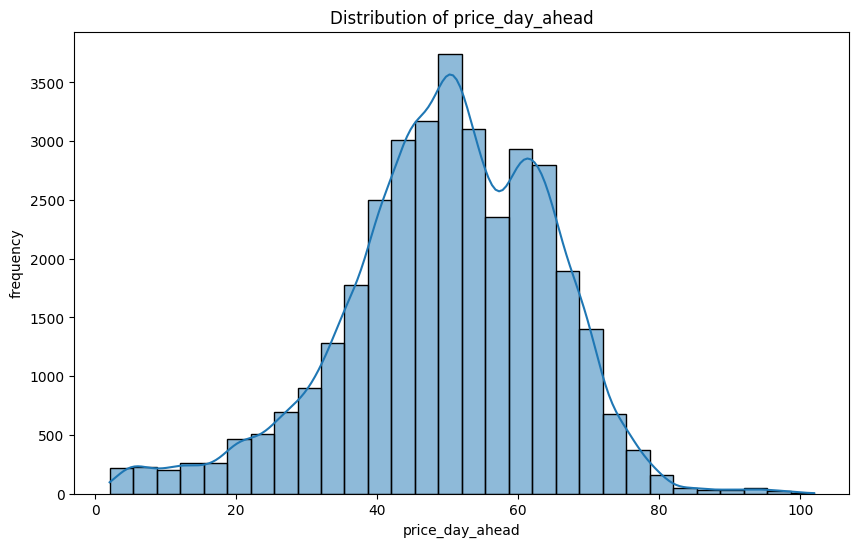

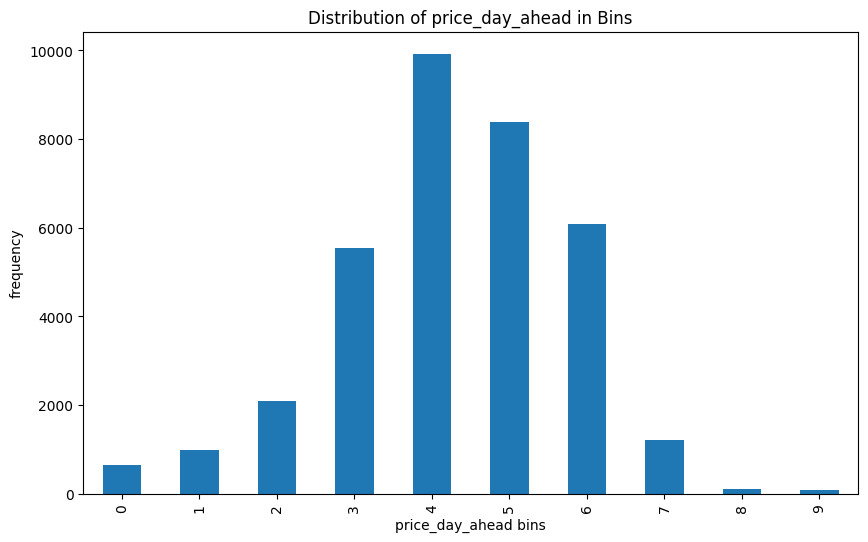

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(df['price_day_ahead'], bins=30, kde=True)
plt.title('Distribution of price_day_ahead')
plt.xlabel('price_day_ahead')
plt.ylabel('frequency')
plt.show()

df['price_day_ahead_bins'] = pd.cut(df['price_day_ahead'], bins=10, labels=False)

# Visualizar a distribuição dos bins
plt.figure(figsize=(10, 6))
df['price_day_ahead_bins'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of price_day_ahead in Bins')
plt.xlabel('price_day_ahead bins')
plt.ylabel('frequency')
plt.show()

The distribution of *'price_day_ahead' shows a pattern with most prices concentrated between 40 and 60. The histograms comfirms that prices follow a distribution close to normality, with a smooth peak around 50 euros, meaning this is the most common price range in the dataset.

When the variable is divided into 10 bins, the central bins (especialy 4.0 and 5.0) contain the largest number of observations, which reinfornces that mid-range prices dominate the dataset. The frequencies drop in the extreme bins (0.0, 1.0, 8.0 and 9.0), indicating that very low and very high prices are rare.

Overall, these results show that electricity prices are relatively stable, concentrated around a central value.

##### Removing Duplicates

In [35]:
df.shape

(35064, 30)

In [36]:
df = df.drop_duplicates()
print('After deleting duplicate values:', df.shape)

After deleting duplicate values: (35064, 30)


With this results, it can be conclued that the dataset did not have any duplicate values

##### Missing Values

In [37]:
missing_values_df = df.isnull().sum()
missing_values_df

time                                               0
generation_biomass                                19
generation_fossil_brown_coal_lignite              18
generation_fossil_coal-derived_gas                18
generation_fossil_gas                             18
generation_fossil_hard_coal                       18
generation_fossil_oil                             19
generation_fossil_oil_shale                       18
generation_fossil_peat                            18
generation_geothermal                             18
generation_hydro_pumped_storage_aggregated     35064
generation_hydro_pumped_storage_consumption       19
generation_hydro_run-of-river_and_poundage        19
generation_hydro_water_reservoir                  18
generation_marine                                 19
generation_nuclear                                17
generation_other                                  18
generation_other_renewable                        18
generation_solar                              